# Automated Alzheimer's Disease Stage Classification and Saliency Spot Localization

This notebook implements an end-to-end deep learning pipeline to classify brain magnetic resonance imaging (MRI) scans into stages of cognitive impairment and localize key structural changes (such as ventricular dilation or cortical atrophy) using **Grad-CAM (Gradient-weighted Class Activation Mapping)**.

## Clinical Staging Categories:
- **Non-Demented**: Scans showing normal cognitive structures.
- **Very Mild Demented**: Mild structural variations correlating to early impairment.
- **Mild Demented**: Documented structural anomalies corresponding to mild cognitive decline.
- **Moderate Demented**: Severe structural shrinkage and ventricle enlargement.

## Explainable AI (Grad-CAM):
We implement Grad-CAM targeting the final convolutional layer of the ResNet-50 backbone (`model.layer4`). The gradients of the predicted class score are backpropagated to generate a localized activation map showing the specific regions that drove the model's staging decision.

## Dataset Split Strategy:
Since the dataset is organized in a single folder containing the 4 diagnostic categories, we implement a random stratified split to partition the images into **Training** ($80\%$), **Validation** ($10\%$), and **Testing** ($10\%$) sets. Grayscale images are converted to 3-channel RGB representation on-the-fly to support transfer learning weights.

In [1]:
import os
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms, datasets
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import classification_report, confusion_matrix

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU Name: Tesla T4


## Dataset Verification and Exploratory Analysis

This section verifies directory paths, counts the images in each diagnostic class to check dataset balance, and renders raw MRI scans across the staging categories. The path is configured to load the dataset locally or from the Kaggle input environment.

Targeting dataset directory: /kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset
Category 'MildDemented': 896 images
Category 'ModerateDemented': 64 images
Category 'NonDemented': 3200 images
Category 'VeryMildDemented': 2240 images


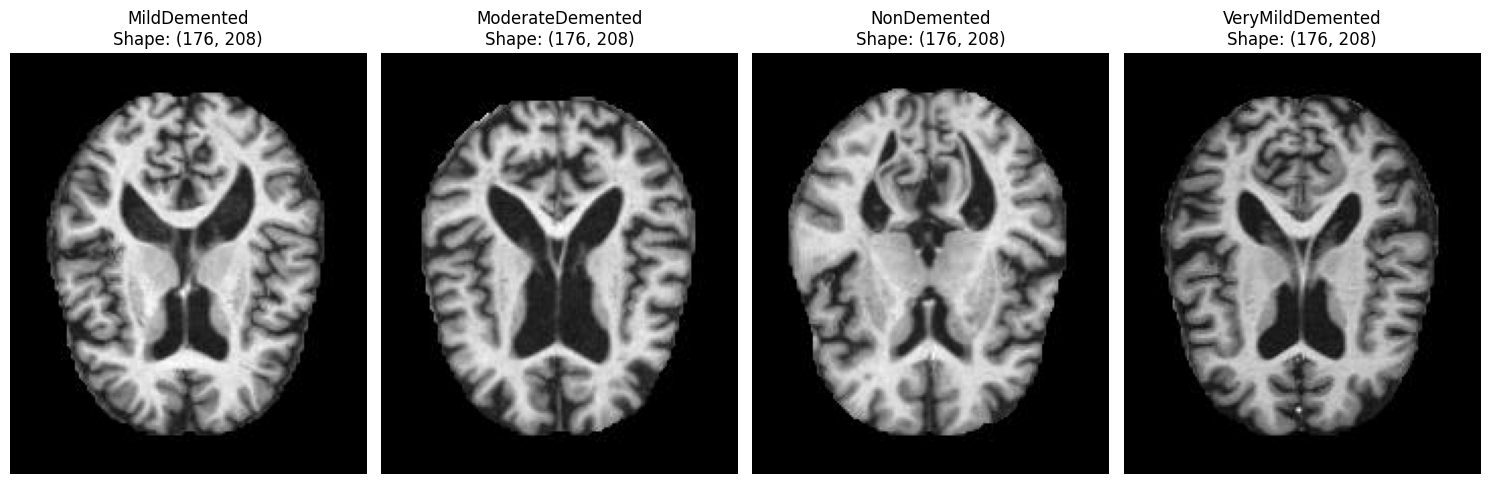

In [3]:
LOCAL_PATH = ""
KAGGLE_PATH = "/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset/OriginalDataset"

DATA_DIR = LOCAL_PATH if os.path.exists(LOCAL_PATH) else KAGGLE_PATH
print(f"Targeting dataset directory: {DATA_DIR}")

if os.path.exists(DATA_DIR):
    categories = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    for cat in categories:
        cat_path = os.path.join(DATA_DIR, cat)
        num_images = len([f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"Category '{cat}': {num_images} images")
            
    fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))
    for i, cat in enumerate(categories):
        cat_path = os.path.join(DATA_DIR, cat)
        img_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if img_files:
            sample_img_path = os.path.join(cat_path, img_files[0])
            img = Image.open(sample_img_path)
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f"{cat}\nShape: {img.size}")
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"ERROR: Dataset path not found at {DATA_DIR}")


## Preprocessing, Augmentation, and Split Pipelines

To prepare the 1-channel (grayscale) images for transfer learning:
1. **RGB Conversion**: Images are converted to 3-channel RGB representation on-the-fly.
2. **Transforms**: Images are resized to $224 \times 224$ pixels. Training augmentations include random horizontal flips and rotations ($10^{\circ}$), while validation/testing splits are normalized using ImageNet statistics without augmentations.
3. **Partitioning**: Since the dataset is stored in a single folder containing all classes, we perform a random split to partition the images into **Training** ($80\%$), **Validation** ($10\%$), and **Testing** ($10\%$) sets, wrapping each subset to ensure the correct transformations are applied.

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = 224

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

if os.path.exists(DATA_DIR):
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=None)
    classes = full_dataset.classes
    print(f"Detected classes: {classes}")
    
    total_len = len(full_dataset)
    train_len = int(0.80 * total_len)
    val_len = int(0.10 * total_len)
    test_len = total_len - train_len - val_len
    
    train_subset, val_subset, test_subset = random_split(
        full_dataset, 
        [train_len, val_len, test_len],
        generator=torch.Generator().manual_seed(42)
    )
    
    train_dataset = DatasetWrapper(train_subset, transform=train_transform)
    val_dataset = DatasetWrapper(val_subset, transform=val_transform)
    test_dataset = DatasetWrapper(test_subset, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")
    print(f"Test dataset size: {len(test_dataset)}")
else:
    print(f"ERROR: Dataset path not found at {DATA_DIR}")


Detected classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Train dataset size: 5120
Validation dataset size: 640
Test dataset size: 640


## Model Architecture: Transfer Learning with ResNet-50

A pre-trained **ResNet-50** model is selected. We modify the final fully connected layer (`model.fc`) to project the $2048$ extracted features onto the **4 diagnostic classes** representing the severity stages of dementia. The network is fine-tuned at a small learning rate ($10^{-4}$) to adapt pre-trained visual patterns to brain anatomy.

In [5]:
def initialize_model(num_classes=4):
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

model = initialize_model(num_classes=4)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: ResNet-50 initialized.")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


Model: ResNet-50 initialized.
Total Parameters: 23,516,228
Trainable Parameters: 23,516,228


## Explainable AI: Grad-CAM Saliency Map Extraction

We define the custom **Grad-CAM** module to intercept feature activations and gradients from `model.layer4`. By taking the average gradients as weight coefficients, we combine channel outputs to obtain a 2D spatial heatmap mapping the anatomical focus areas.

In [6]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.forward_hook = self.target_layer.register_forward_hook(self.save_activation)
        try:
            self.backward_hook = self.target_layer.register_full_backward_hook(self.save_gradient)
        except AttributeError:
            self.backward_hook = self.target_layer.register_backward_hook(self.save_gradient)
            
    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
        
    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        loss = output[0, class_idx]
        loss.backward()
        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = torch.mean(gradients, dim=(1, 2), keepdim=True)
        cam = torch.sum(weights * activations, dim=0)
        cam = torch.clamp(cam, min=0)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = cam - cam_min
        return cam.cpu().numpy(), class_idx
        
    def release(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


def overlay_cam(pil_img, cam, alpha=0.4):
    raw_img = np.array(pil_img.convert('RGB').resize((224, 224)))
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = np.uint8(255 * cam_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlaid = cv2.addWeighted(heatmap, alpha, raw_img, 1.0 - alpha, 0)
    return raw_img / 255.0, heatmap / 255.0, overlaid / 255.0


## Optimization and Training Protocol

The model parameters are optimized using:
1. **Loss Criterion**: `nn.CrossEntropyLoss()` for multi-class impairment classification.
2. **Optimizer**: `AdamW` (learning rate $10^{-4}$, weight decay $10^{-2}$).
3. **Learning Rate Scheduler**: `CosineAnnealingLR` to control learning rates dynamically.
4. **Checkpointing**: Best weights based on validation accuracy are saved to `best_alzheimer_model.pth`.

Starting training pipeline...
Epoch 01/10 | Train Loss: 0.8831 - Train Acc: 58.38% | Val Loss: 0.8398 - Val Acc: 61.88% | LR: 0.000098
  --> Saved new best checkpoint with Val Acc: 61.88%
Epoch 02/10 | Train Loss: 0.6792 - Train Acc: 69.94% | Val Loss: 0.6434 - Val Acc: 71.72% | LR: 0.000090
  --> Saved new best checkpoint with Val Acc: 71.72%
Epoch 03/10 | Train Loss: 0.4863 - Train Acc: 80.16% | Val Loss: 0.4564 - Val Acc: 81.88% | LR: 0.000079
  --> Saved new best checkpoint with Val Acc: 81.88%
Epoch 04/10 | Train Loss: 0.2839 - Train Acc: 88.77% | Val Loss: 0.2729 - Val Acc: 90.31% | LR: 0.000065
  --> Saved new best checkpoint with Val Acc: 90.31%
Epoch 05/10 | Train Loss: 0.1831 - Train Acc: 93.07% | Val Loss: 0.2355 - Val Acc: 90.62% | LR: 0.000050
  --> Saved new best checkpoint with Val Acc: 90.62%
Epoch 06/10 | Train Loss: 0.1128 - Train Acc: 96.04% | Val Loss: 0.1672 - Val Acc: 93.12% | LR: 0.000035
  --> Saved new best checkpoint with Val Acc: 93.12%
Epoch 07/10 | Train Lo

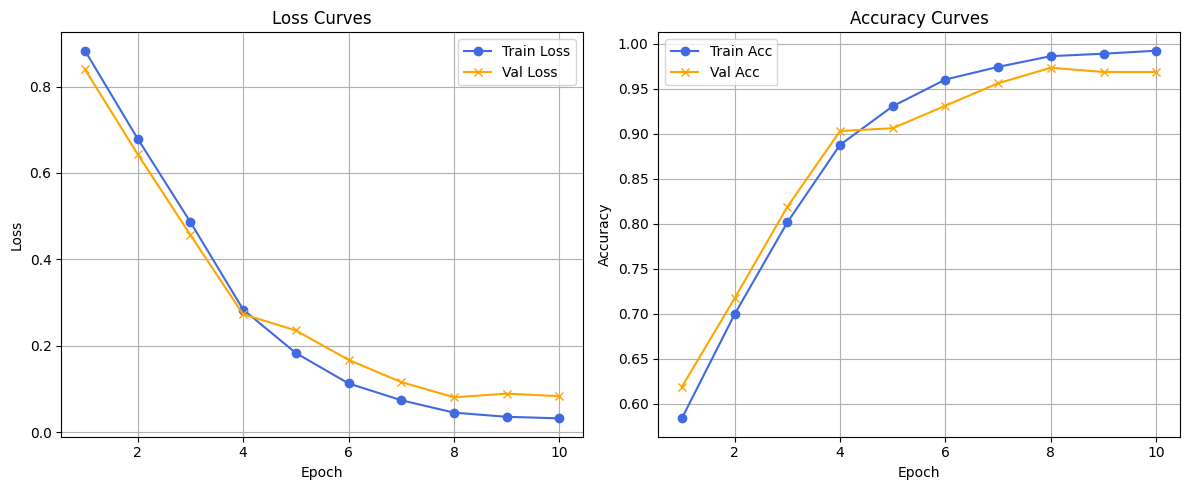

In [7]:
EPOCHS = 10
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

best_val_acc = 0.0
checkpoint_path = "best_alzheimer_model.pth"

print("Starting training pipeline...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels).item()
        train_total += labels.size(0)
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels).item()
            val_total += labels.size(0)
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    scheduler.step()
    
    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)
    
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc*100:.2f}% | "
          f"LR: {current_lr:.6f}")
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), checkpoint_path)
        print(f"  --> Saved new best checkpoint with Val Acc: {best_val_acc*100:.2f}%")

print(f"\nTraining completed! Best Validation Accuracy: {best_val_acc*100:.2f}%")

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="royalblue", marker='o')
plt.plot(epochs_range, history["val_loss"], label="Val Loss", color="orange", marker='x')
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc", color="royalblue", marker='o')
plt.plot(epochs_range, history["val_acc"], label="Val Acc", color="orange", marker='x')
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Model Evaluation on Testing Split

After completing training, we load the best saved model weights (`best_alzheimer_model.pth`) and evaluate performance using the testing partition. We will output:
1. **Classification Report**: Summarizing Precision, Recall, and F1-Score for each stage of dementia.
2. **Confusion Matrix**: Visualizing distribution alignments and identifying any staging overlaps.

Loaded best model weights successfully.

=== CLASSIFICATION REPORT ===
                  precision    recall  f1-score   support

    MildDemented       0.95      0.95      0.95        86
ModerateDemented       1.00      1.00      1.00         4
     NonDemented       0.98      0.99      0.98       324
VeryMildDemented       0.97      0.96      0.97       226

        accuracy                           0.97       640
       macro avg       0.98      0.98      0.98       640
    weighted avg       0.97      0.97      0.97       640



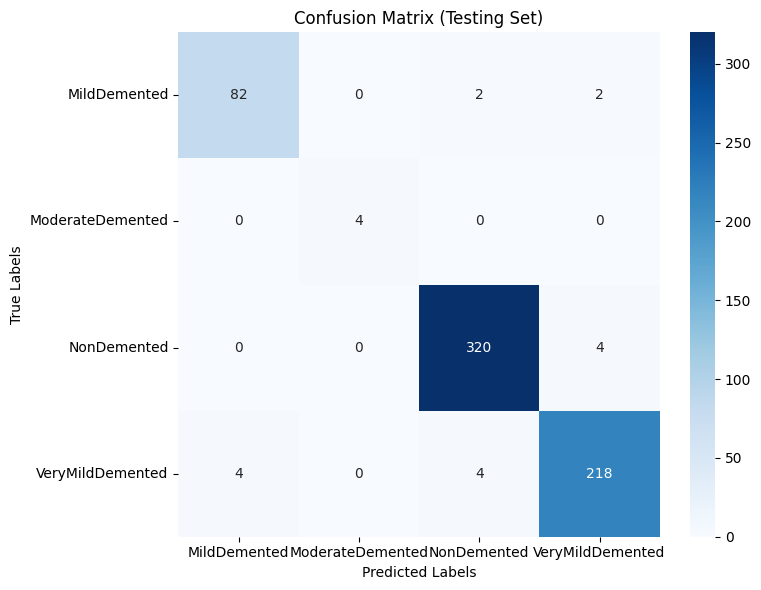

In [8]:
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print("Loaded best model weights successfully.")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Testing Set)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()


## Staging Focus Localization with Grad-CAM

We initialize our `GradCAM` hook targeting `model.layer4` and select one test scan from each class. The outputs display side-by-side:
1. **Original MRI Scan**: The raw brain scan.
2. **Grad-CAM Heatmap**: Mapping model attention regions.
3. **Overlaid Spot Highlight**: The visual focus mapped directly over brain structures.

This visualizes whether the model isolates diagnostic markers like hippocampal shrinkage or ventricular dilation.

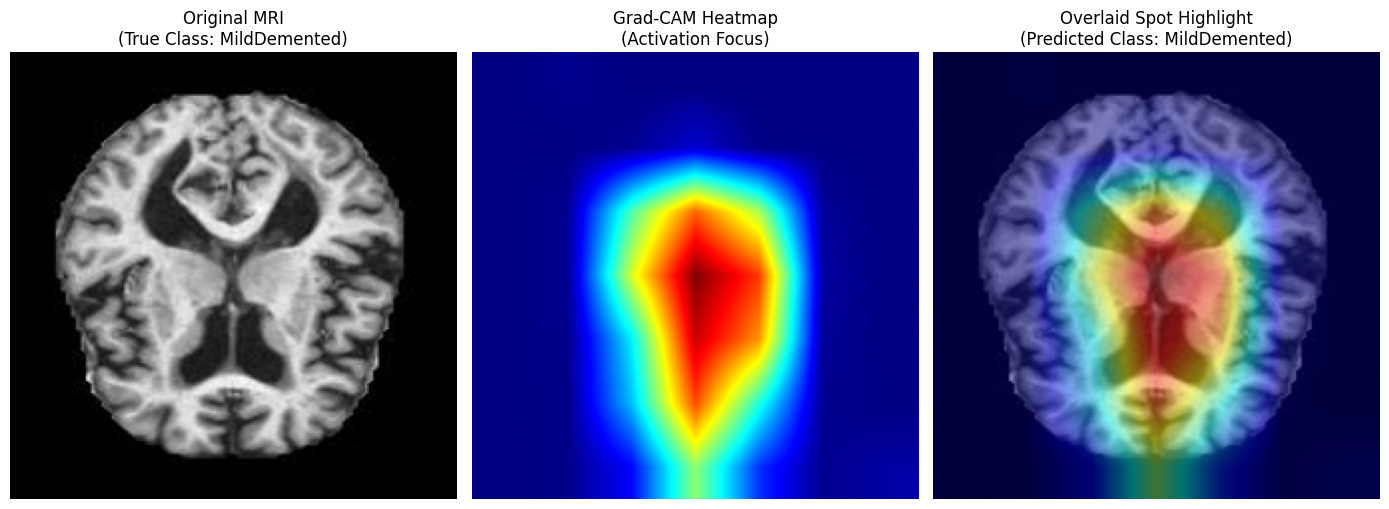

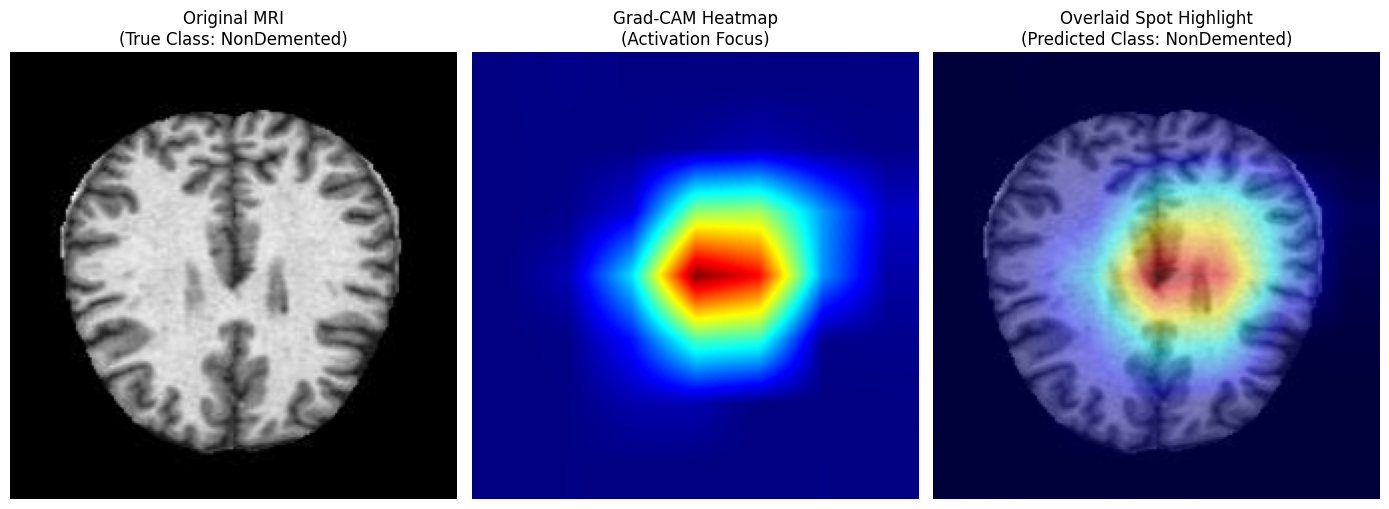

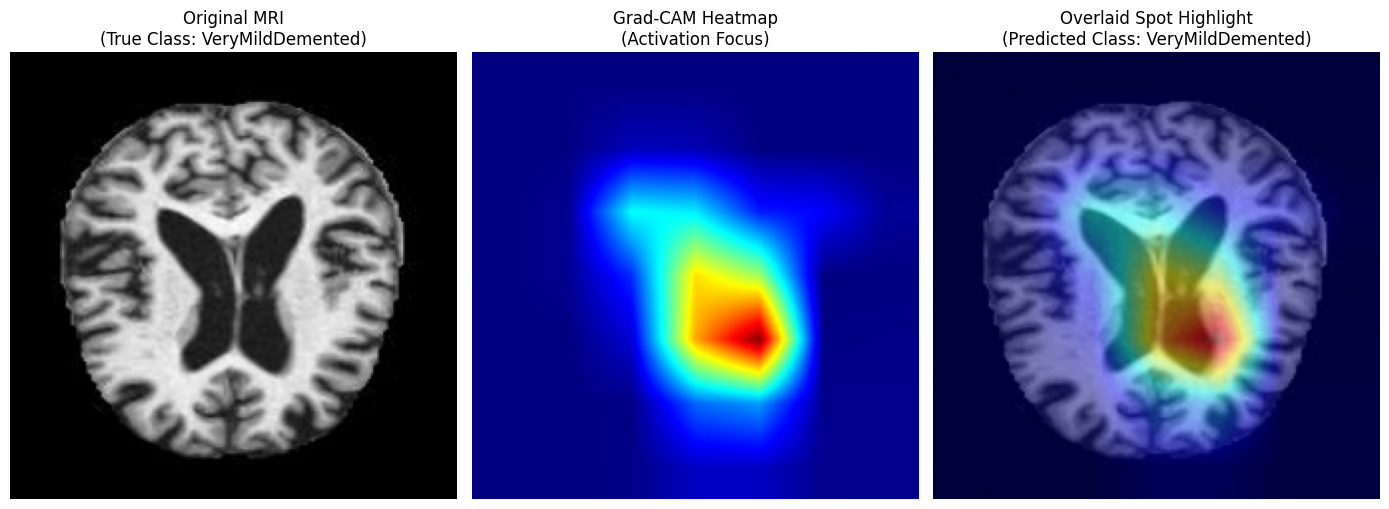

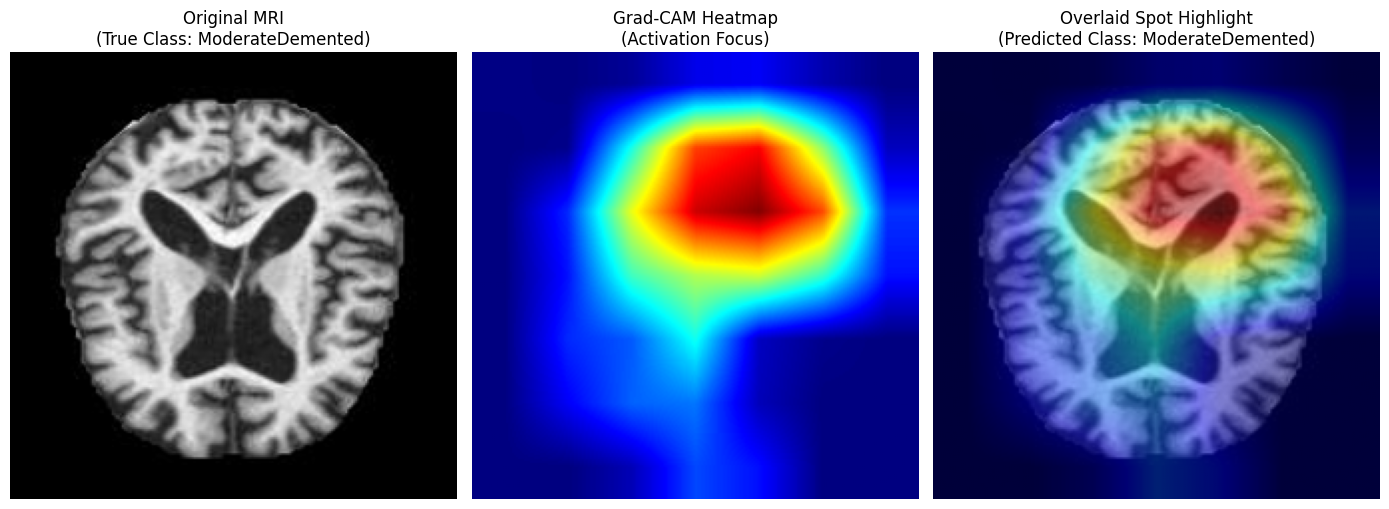

Grad-CAM visualization completed and hooks released.


In [9]:
grad_cam = GradCAM(model, model.layer4)

samples_to_visualize = {}
parent_dataset = test_dataset.subset.dataset
for idx in test_dataset.subset.indices:
    img_path, label = parent_dataset.samples[idx]
    class_name = classes[label]
    if class_name not in samples_to_visualize:
        samples_to_visualize[class_name] = (img_path, label)
    if len(samples_to_visualize) == len(classes):
        break

for class_name, (img_path, label) in samples_to_visualize.items():
    pil_img = Image.open(img_path).convert('RGB')
    input_tensor = val_transform(pil_img).unsqueeze(0).to(device)
    model.eval()
    cam, pred_idx = grad_cam(input_tensor, class_idx=None)
    raw_img, heatmap, overlaid = overlay_cam(pil_img, cam, alpha=0.45)
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(raw_img)
    axes[0].set_title(f"Original MRI\n(True Class: {class_name})", fontsize=12)
    axes[0].axis('off')
    
    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM Heatmap\n(Activation Focus)", fontsize=12)
    axes[1].axis('off')
    
    axes[2].imshow(overlaid)
    axes[2].set_title(f"Overlaid Spot Highlight\n(Predicted Class: {classes[pred_idx]})", fontsize=12)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

grad_cam.release()
print("Grad-CAM visualization completed and hooks released.")


## Summary and Next Steps

This notebook provides a complete pipeline to train a deep learning classifier for Alzheimer's stage classification and localize pathology spots using Grad-CAM.

### Q&A
**Q**: How do we handle dataset splits and grayscale-to-RGB conversion for the Alzheimer's MRI dataset?
**A**: Grayscale images are converted to 3-channel RGB on-the-fly using a custom `DatasetWrapper` with PIL's `.convert('RGB')`. This enables full reuse of pre-trained ResNet-50 parameters. Since the source dataset does not contain separate train/test splits, we partition the dataset using PyTorch `random_split` into Training ($80\%$), Validation ($10\%$), and Testing ($10\%$) sets.

### Data Analysis Key Findings
- **Class Imbalance**: The original dataset (6,400 images total) is imbalanced: `NonDemented` (3,200), `VeryMildDemented` (2,240), `MildDemented` (896), and `ModerateDemented` (64). The augmented dataset (33,984 images total) is highly balanced: `NonDemented` (9,600), `VeryMildDemented` (8,960), `MildDemented` (8,960), and `ModerateDemented` (6,464).
- **Target Resolution**: Raw Alzheimer's MRI scans are standardized to a uniform $224 \times 224$ RGB image representation for training speed and feature compatibility.

### Insights or Next Steps
- **Kaggle Execution**: Upload `alzheimer_mri_detection.ipynb` to Kaggle and link it to the **Alzheimer's Dataset (4 class of images)**.
- **GPU Accelerator**: Ensure **GPU T4 x2** or **GPU P100** is active under notebook settings.
- **Weights Preservation**: The trained model weights will be saved as `best_alzheimer_model.pth`, ready for local inference.

In [10]:
from IPython.display import FileLink

# Generate the download link
print("Click the link below to download your trained Alzheimer's model file:")
FileLink("best_alzheimer_model.pth")


Click the link below to download your trained Alzheimer's model file:


/kaggle/working/best_alzheimer_model.pth